In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandapipes as pp
from pandapipes.properties.fluids import create_constant_fluid
import os

In [4]:
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.dpi"] = 300

font_size = 16
mpl.rcParams["font.size"] = font_size
mpl.rcParams["axes.titlesize"] = font_size
mpl.rcParams["axes.labelsize"] = font_size
mpl.rcParams["xtick.labelsize"] = font_size
mpl.rcParams["ytick.labelsize"] = font_size
mpl.rcParams["legend.fontsize"] = font_size
mpl.rcParams["figure.titlesize"] = font_size

In [7]:
base_path = os.getcwd()
results_folder = os.path.join(base_path, 'Results')

if not os.path.exists(results_folder):
    os.makedirs(results_folder)

# Load network data

In [5]:
# --- network input data ---
delta_t_consumers = 30      # K
t_supply_producer = 70      # °C
t_ext_ground = 10           # °C


nodes_file = "InputData/nodes_data.csv"
pipes_file = "InputData/pipes_data.csv"

# Load csv data for heat profile at substations
profile_data = pd.read_csv("InputData/heat_profile_1_building_SFH_Network_1.csv")[:1008]
time = profile_data["Elapsed time [sec]"].values
qext_w = profile_data["Building heat demand [W]"].values
NUM_SIM_STEPS = len(qext_w)

deltat_k = np.ones_like(qext_w) * delta_t_consumers

Image saved in: C:\Users\sara.ferrero\PycharmProjects\OSMSES_2026_Ferrero\Results\building_heating_load.tiff


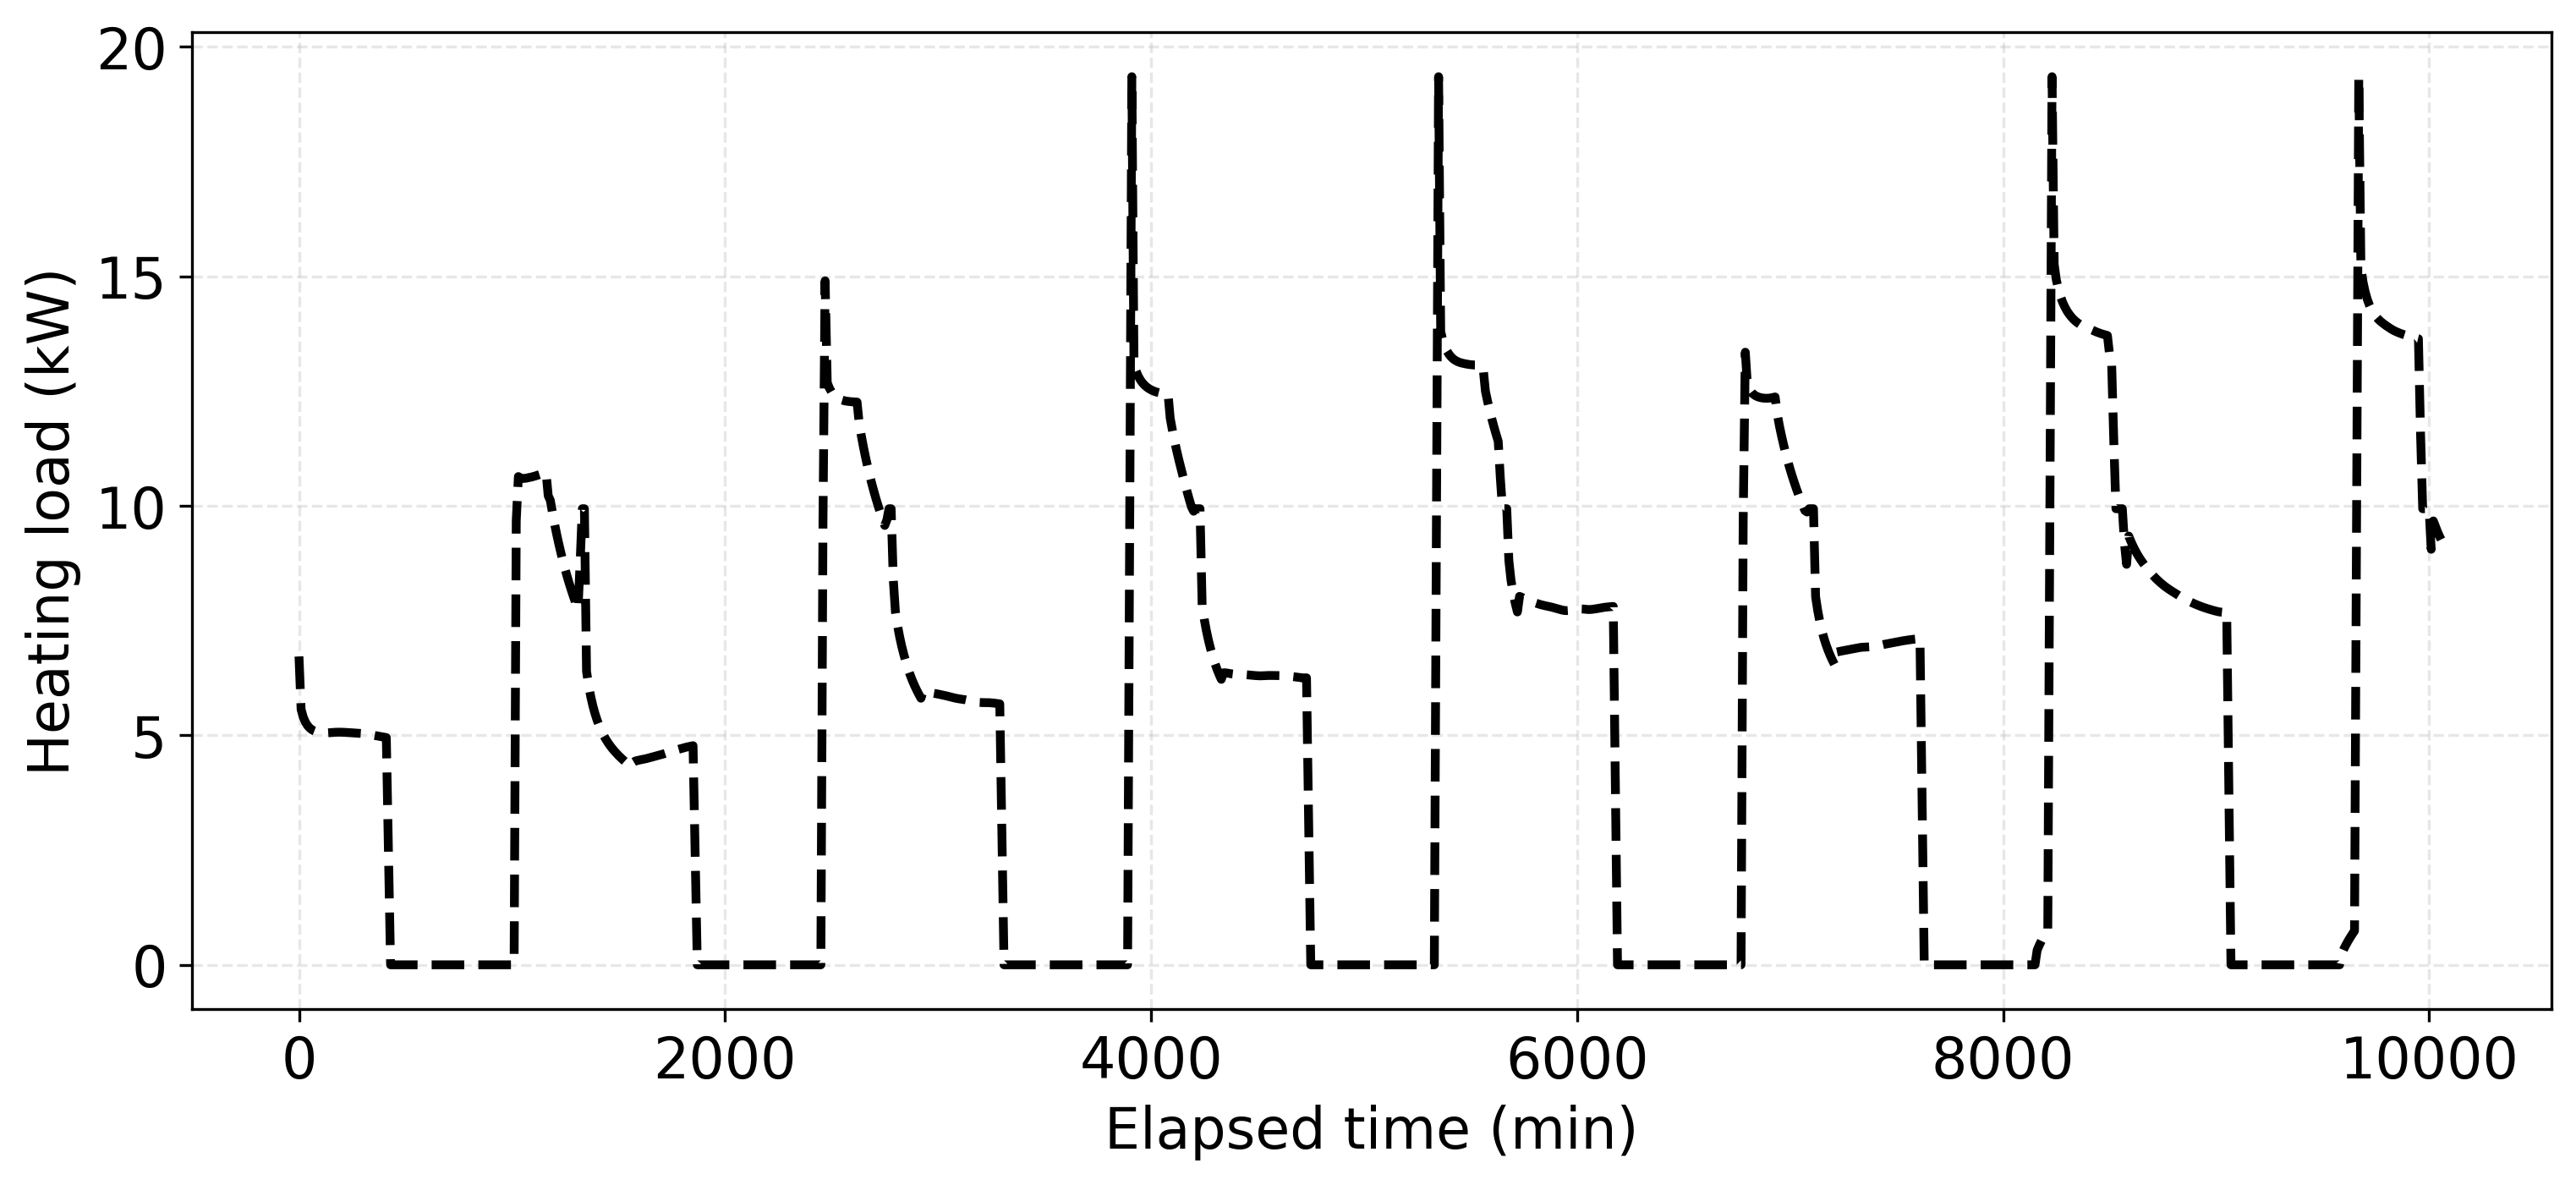

In [8]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(profile_data["Elapsed time [sec]"]/60, profile_data["Building heat demand [W]"]/1000, color="black", lw=2.5, linestyle='--')

ax.set_ylabel("Heating load (kW)")
ax.set_xlabel("Elapsed time (min)")

ax.grid(True, linestyle='--', alpha=0.3)

plot_filename = os.path.join(results_folder, "building_heating_load.tiff")

plt.savefig(
    plot_filename,
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

print(f"Image saved in: {plot_filename}")
plt.show()

# Network setup

In [9]:
offset=(0.5,0.5,0.15)

# --- initialization ---
t_initial = 20              # °C
p_initial = 1               # bar


# --- READ DATA ---
nodes = pd.read_csv(nodes_file, sep=';')
pipes = pd.read_csv(pipes_file, sep=';')

# --- Heat transfer coefficient calculation dfrom input data ---
def calculate_u_w_per_m2k(row):
    d_int = row['diameter_m']
    t_int = row['t_pipe_m']
    t_ins = row['t_ins_m']
    t_ext = 0.0

    lambda_int = 0.35   # W/mK
    lambda_ins = 0.026  # W/mK
    lambda_c = 0.4      # W/mK

    r_int = d_int / 2
    r_1 = r_int + t_int
    r_2 = r_1 + t_ins
    r_ext = r_2 + t_ext

    R_prime_int = np.log(r_1 / r_int) / (2 * np.pi * lambda_int)
    R_prime_ins = np.log(r_2 / r_1) / (2 * np.pi * lambda_ins)
    R_prime_c = np.log(r_ext / r_2) / (2 * np.pi * lambda_c)

    R_prime_global = R_prime_int + R_prime_ins + R_prime_c

    U_L = 1 / R_prime_global
    U = U_L / (2 * np.pi * r_int)

    return U

pipes["u_w_per_m2k"] = pipes.apply(calculate_u_w_per_m2k, axis=1)

# --- CREATE NETWORK ---
net = pp.create_empty_network(name="Network_0")

# --- DEFINE FLUID ---
fluid_props = dict(
    name="water_50",
    fluid_type="liquid",
    density=988,
    viscosity=0.0005434,
    heat_capacity=4180,
    thermal_conductivity=0.64,
    temperature=50 + 273.15
)

fluid = create_constant_fluid(**fluid_props)
net.fluid = fluid

# --- NODES ---
node_map = {}
for idx, row in nodes.iterrows():
    name = row["node_id"]
    name_s = f"{name}_s"
    name_r = f"{name}_r"

    # supply junction
    j_s = pp.create_junction(
        net,
        pn_bar=p_initial,
        tfluid_k=t_initial + 273.15,
        height_m=row.get("z",0),
        name=name_s,
        geodata=(row["x"], row["y"])
    )
    # return junction
    j_r = pp.create_junction(
        net,
        pn_bar=p_initial,
        tfluid_k=t_initial + 273.15,
        height_m=row.get("z",0),
        name=name_r,
        geodata=(row["x"] + offset[0], row["y"] + offset[1])
    )

    node_map[name] = {"supply": j_s, "return": j_r}

    # --- SUBSTATIONS ---
    if "SimpleDistrict" in name:
        pp.create_heat_consumer(
            net,
            from_junction=j_s,
            to_junction=j_r,
            deltat_k=deltat_k[0],
            qext_w=qext_w[0],
            name=name
        )

    # --- HEATING STATION ---
    if name == "i":
        pp.create_circ_pump_const_pressure(
            net,
            return_junction=j_r,
            flow_junction=j_s,
            p_flow_bar=p_initial,
            plift_bar=0.10,
            t_flow_k=t_supply_producer + 273.15,
            name="Producer"
        )

# --- PIPES ---
for idx, row in pipes.iterrows():
    start = row["start_node"]
    end = row["end_node"]
    name_s = f"{start}_to_{end}_s"
    name_r = f"{start}_to_{end}_r"

    start_s = node_map[start]["supply"]
    end_s   = node_map[end]["supply"]
    start_r = node_map[end]["return"]
    end_r   = node_map[start]["return"]

    # supply
    pp.create_pipe_from_parameters(
        net,
        from_junction=start_s,
        to_junction=end_s,
        length_km=row["length_m"]/1000,
        diameter_m=row["diameter_m"],
        k_mm=0.007,
        u_w_per_m2k=row["u_w_per_m2k"],
        text_k=t_ext_ground + 273.15,
        name=name_s
    )

    # return
    pp.create_pipe_from_parameters(
        net,
        from_junction=start_r,
        to_junction=end_r,
        length_km=row["length_m"]/1000,
        diameter_m=row["diameter_m"],
        k_mm=0.007,
        u_w_per_m2k=row["u_w_per_m2k"],
        text_k=t_ext_ground + 273.15,
        name=name_r
    )

# Pipeflow calculation

In [10]:
pp.pipeflow(net, mode="bidirectional", friction_model="colebrook", transient=True)

# Time series simulation

In [11]:
# --- Heat demand equal to zero management ---

# Boundary cond. on heat demand of heat_consumers
qext_profile = pd.DataFrame(
    data=np.tile(qext_w.reshape(-1, 1), (1, len(net.heat_consumer.index.values))),
    columns=net.heat_consumer.name.values
)

# Boundary cond. on temperature difference of heat_consumers
deltat_profile = pd.DataFrame(
    data=np.tile(deltat_k.reshape(-1, 1), (1, len(net.heat_consumer.index.values))),
    columns=net.heat_consumer.name.values
)
deltat_min = 1e-5
qext_min = 1e-5
mask = qext_profile < qext_min
deltat_profile[mask] = deltat_min
qext_profile[mask] = qext_min

In [13]:
# --- DFData ---
from pandapower.timeseries import DFData

qext_profile_data  = DFData(qext_profile)
deltat_profile_data = DFData(deltat_profile)

print("--- Data setup is defined. ---")

--- Data setup is defined. ---


In [14]:
from pandapower.control.controller.const_control import ConstControl
from pandapower.control.basic_controller import Controller


for i, hc_idx in enumerate(net.heat_consumer.index):

    ConstControl(
        net,
        element="heat_consumer",
        variable="qext_w",
        element_index=hc_idx,
        profile_name=net.heat_consumer.name.values[i],
        data_source=qext_profile_data
    )

    ConstControl(
        net,
        element="heat_consumer",
        variable="deltat_k",
        element_index=hc_idx,
        profile_name=net.heat_consumer.name.values[i],
        data_source=deltat_profile_data
    )

# Enahnced pandapipes model

In [15]:
import networkx as nx

def compute_upstream_thermal_parameters(
    pipes,
    net,
    producer_node="i",
    round_digits=2
):
    """
    Compute upstream thermal parameters (tau, td) for each node.
    """

    # Pipe thermal parameters
    r_int = pipes["diameter_m"] / 2
    r_pipe_ext = r_int + pipes["t_pipe_m"]
    r_ins_ext = r_pipe_ext + pipes["t_ins_m"]

    rho_w, cp_w = fluid_props["density"], fluid_props["heat_capacity"]
    rho_p, cp_p = 940, 2000
    rho_ins, cp_ins = 50, 1500

    vol_w = np.pi * r_int**2 * pipes["length_m"]
    vol_p = np.pi * (r_pipe_ext**2 - r_int**2) * pipes["length_m"]
    vol_ins = np.pi * (r_ins_ext**2 - r_pipe_ext**2) * pipes["length_m"]

    pipes["Cth"] = (
        rho_w * cp_w * vol_w +
        rho_p * cp_p * vol_p +
        rho_ins * cp_ins * vol_ins
    )

    pipes["surface_m2"] = 2 * np.pi * r_pipe_ext * pipes["length_m"]

    pipes["tau"] = (
        pipes["Cth"] / (
            net.pipe["u_w_per_m2k"] * pipes["surface_m2"]
        ).replace(0, 1e-9)
    ) / 60

    pipes["td"] = (
        pipes["length_m"] /
        net.res_pipe["v_mean_m_per_s"].replace(0, 1e-9)
    ) / 60

    # Build directed graph
    G = nx.DiGraph()
    for pid, row in pipes.iterrows():
        G.add_edge(
            row["start_node"],
            row["end_node"],
            pipe_id=pid
        )

    # Supply nodes
    supply_nodes = [
        name.replace("_s", "")
        for name in net.junction.loc[
            net.junction["name"].str.endswith("_s", na=False),
            "name"
        ]
    ]

    # Check nodes
    missing_nodes = set(supply_nodes) - set(G.nodes)
    if missing_nodes:
        raise ValueError(f"Nodi supply non presenti nel grafo: {missing_nodes}")

    # Compute upstream parameters
    rows = []

    for node in supply_nodes:
        if node == producer_node:
            continue

        if not nx.has_path(G, producer_node, node):
            continue

        path = nx.shortest_path(G, source=producer_node, target=node)

        pipe_ids = [
            G.edges[path[i], path[i + 1]]["pipe_id"]
            for i in range(len(path) - 1)
        ]

        pipes_upstream = pipes.loc[pipe_ids]

        Cth_up = pipes_upstream["Cth"].sum()
        R_up = (pipes_upstream["u_w_per_m2k"] * pipes_upstream["surface_m2"]).sum()

        tau_node = Cth_up / R_up / 60           # min
        td_node = pipes_upstream["td"].sum()    # min

        pipe_repr = [
            f"{row.start_node} → {row.end_node}"
            for _, row in pipes_upstream.iterrows()
        ]

        rows.append({
            "node": node,
            "path_nodes": path,
            "n_pipes_upstream": len(pipe_ids),
            "pipes_upstream": pipe_repr,
            "tau": tau_node,
            "td": td_node
        })

    results = pd.DataFrame(rows).set_index("node")

    tau = results["tau"].to_dict()
    td = results["td"].to_dict()

    def show():
        display(results.round(round_digits))

    results.show = show

    return results, tau, td


df_upstream, tau, td = compute_upstream_thermal_parameters(
    pipes=pipes,
    net=net,
    producer_node="i"
)

node_to_idx = {
    name.replace("_s", ""): idx
    for idx, name in net.junction["name"].items()
}
df_upstream.index = [node_to_idx.get(n, n) for n in df_upstream.index]

In [16]:
import ruptures as rpt

def compute_cpd(qext_w, dtime=10, threshold_off=1e-1, n_segments_on=2):
    """
    Change Point Detection for demand profile
    """
    n_steps = len(qext_w)
    times = np.arange(0, n_steps * dtime, dtime)
    days = times // 1440

    df = pd.DataFrame({"time": times, "demand": qext_w, "day": days})
    cpd_list = []

    for day, group in df.groupby("day"):
        group = group.copy()
        mask_off = group["demand"] < threshold_off

        mask_off_extended = mask_off.copy()
        mask_off_extended[:-1] = mask_off_extended[:-1] | mask_off[1:].values   # include next
        mask_off_extended[1:] = mask_off_extended[1:] | mask_off[:-1].values   # include previous

        group["segment"] = np.where(mask_off_extended, "off", "on")
        mask_on = ~mask_off_extended

        if mask_on.sum() > 1:
            signal_on = group.loc[mask_on, "demand"].values
            algo = rpt.Binseg(model="l2").fit(signal_on)
            change_points = algo.predict(n_bkps=n_segments_on - 1)

            segment_labels = np.zeros(len(signal_on), dtype=int)
            start = 0
            for i, end in enumerate(change_points):
                segment_labels[start:end] = i
                start = end

            seg_map_on = {0: "base", 1: "peak"}
            group.loc[mask_on, "segment"] = [seg_map_on[i] for i in segment_labels]

        cpd_list.append(group)

    cpd_segmented = pd.concat(cpd_list, ignore_index=True)
    cpd_segmented = cpd_segmented.set_index("time")
    return cpd_segmented


cpd_segmented = compute_cpd(qext_w, dtime=10, threshold_off=1e-1, n_segments_on=2)
cpd_segmented = cpd_segmented.reset_index().set_index('time')

CPD algortithm grpah saved in: C:\Users\sara.ferrero\PycharmProjects\OSMSES_2026_Ferrero\Results\CPD_building_heating_load.tiff


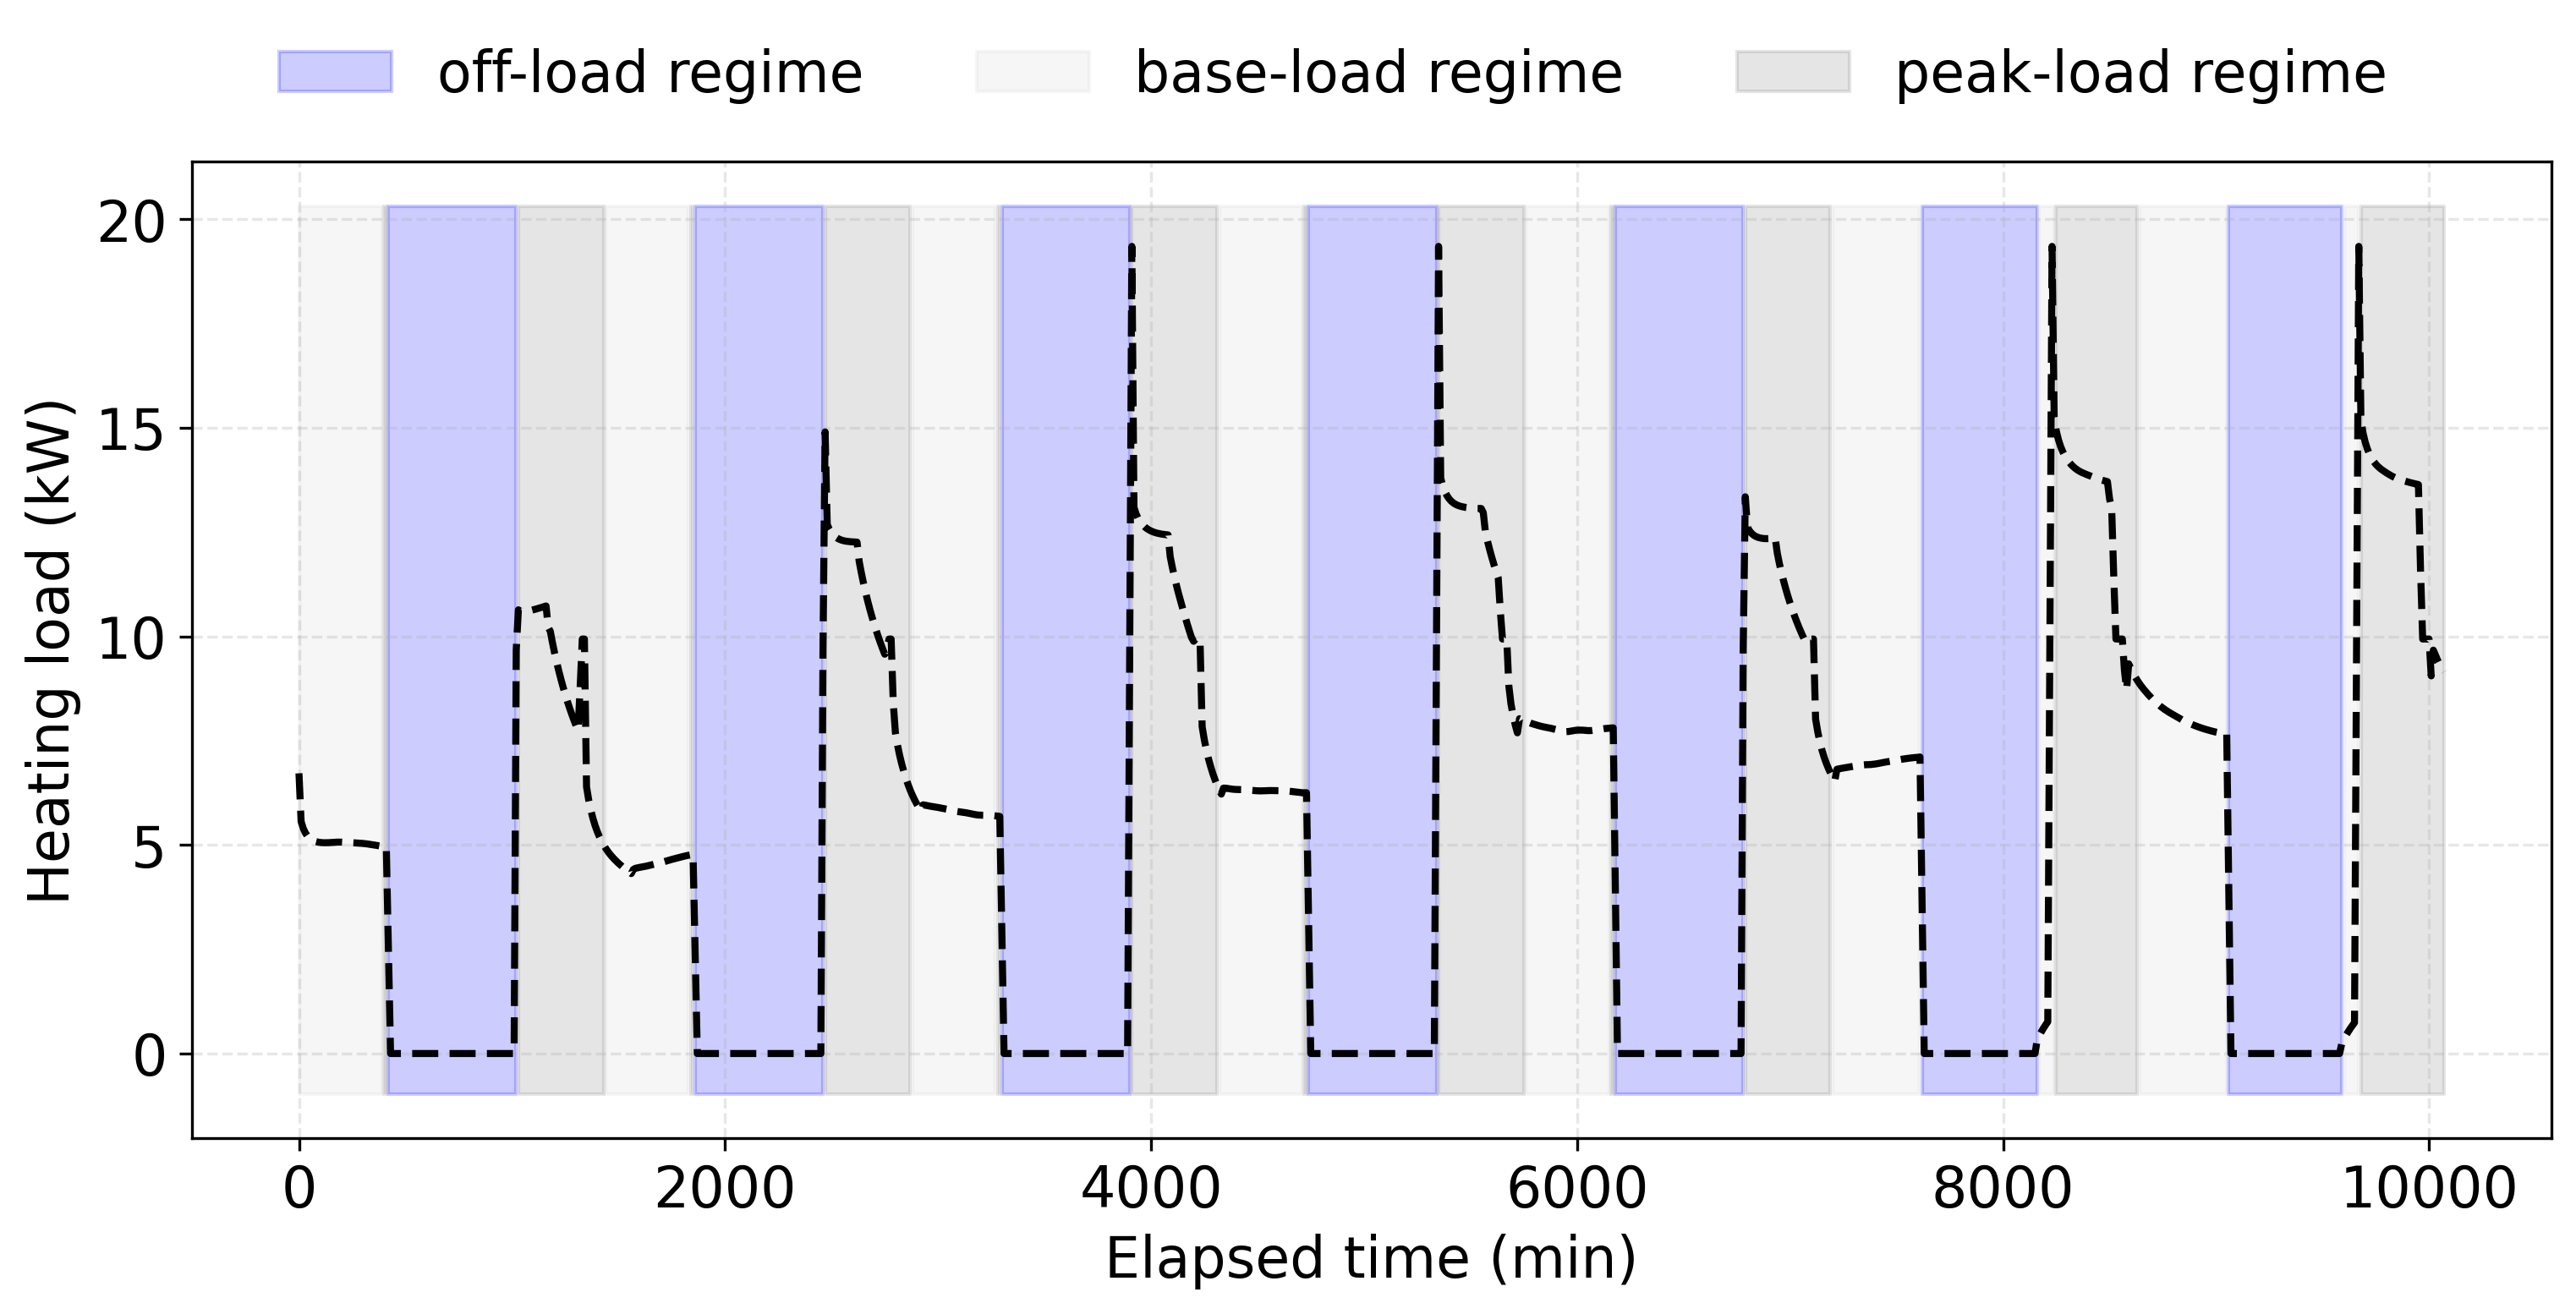

In [18]:
segment_colors_map = {
    "off": "blue",
    "base": "lightgrey",
    "peak": "grey"
}

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(cpd_segmented.index, cpd_segmented["demand"]/1000, color="black", lw=2, linestyle='--')

ax.set_ylabel("Heating load (kW)")
ax.set_xlabel("Elapsed time (min)")
ax.grid(True, linestyle='--', alpha=0.3)

ymin, ymax = ax.get_ylim()

for seg in ["off", "base", "peak"]:
    if seg in cpd_segmented["segment"].unique():
        mask = cpd_segmented["segment"] == seg
        ax.fill_between(
            cpd_segmented.index, ymin, ymax,
            where=mask,
            color=segment_colors_map.get(seg, "#cccccc"),
            alpha=0.2,
            label=f"{seg}-load regime"
        )

fig.legend(loc="upper center",
           bbox_to_anchor=(0.5, 1.01),
           ncol=3,
           frameon=False)

cpd_plot_path = os.path.join(results_folder, "CPD_building_heating_load.tiff")
plt.savefig(
    cpd_plot_path,
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

print(f"CPD algortithm grpah saved in: {cpd_plot_path}")
plt.show()

In [19]:
class TempControll(Controller):

    def __init__(
        self,
        net,
        steps,
        cpd_segmented,
        df_upstream,
        dtime=10.0,
        t_ext_ground=10.0,
        producer_node=None,
        **kwargs
    ):
        super().__init__(net, **kwargs)

        self.net = net
        self.steps = steps
        self.cpd_segmented = cpd_segmented
        self.df_upstream = df_upstream
        self.dtime = dtime
        self.t_ext_ground = t_ext_ground
        self.producer_node = producer_node

        # supply nodes
        self.supply_nodes = net.junction.loc[net.junction["name"].str.endswith("_s") & (net.junction["name"] != producer_node), "name"].tolist()

        # new temperature profile memory
        self.t_dy_k = pd.DataFrame(
            index=steps,
            columns=self.net.junction.index,
            dtype=float
        )

        # OFF state memory
        self.time_start_off = {node: None for node in self.supply_nodes}
        self.prev_seg = "on"


    def time_step(self, net, time):

        current_time = time * self.dtime
        raw_seg = self.cpd_segmented.loc[self.cpd_segmented.index == current_time, "segment"].values[0]

        is_currently_off = (raw_seg == "off")
        was_previously_off = (self.prev_seg == "off")

        for node_idx in net.junction.index:
            node_name = net.junction.at[node_idx, "name"]

            if node_name in self.supply_nodes:

                tau = self.df_upstream.at[node_idx, "tau"]
                td = self.df_upstream.at[node_idx, "td"]

                # OFF start detection
                if is_currently_off and not was_previously_off:
                    self.time_start_off[node_name] = current_time

                # --- OFF band where correct ---
                if is_currently_off:

                        dt_since_off = current_time - self.time_start_off[node_name]

                        if dt_since_off > td:

                            # TEMPERATURE PROFILE CORRECTION

                            # memorization of previous corrected temperature
                            if time > 0 and not np.isnan(self.t_dy_k.at[time - 1, node_idx]):
                                t_prev = self.t_dy_k.at[time - 1, node_idx]
                            else:
                                t_prev = net.res_junction.at[node_idx, "t_k"]

                            # dynamic integration (correction)
                            dt_eff = min(self.dtime, dt_since_off - td)
                            t_k_new = (self.t_ext_ground + (t_prev - self.t_ext_ground) * np.exp(-dt_eff / tau))

                        else:
                            # "cold front" has not yet arrived
                            t_k_new = net.res_junction.at[node_idx, "t_k"]

                # --- ON band where NON correct ---
                else:
                    t_k_new = net.res_junction.at[node_idx, "t_k"]
                    self.time_start_off[node_name] = None

            # RETURN / PRODUCER (no correction)
            else:
                t_k_new = net.res_junction.at[node_idx, "t_k"]

            # update network
            net.res_junction.at[node_idx, "t_k"] = t_k_new
            self.t_dy_k.at[time, node_idx] = t_k_new

        self.prev_seg = raw_seg


    def is_converged(self, net):
        return True


dy_controller = TempControll(net, list(range(NUM_SIM_STEPS)), cpd_segmented, df_upstream, dtime=10.0, t_ext_ground=t_ext_ground + 273.15, producer_node="i_s")

In [20]:
# --- Run time series ---

from pandapipes.timeseries import run_time_series
from pandapower.timeseries import OutputWriter

log_variables = [
    ('res_junction', 't_k'),
    ('res_pipe', 'mdot_from_kg_per_s'),
    ('res_heat_consumer', 't_from_k'),
    ('res_heat_consumer', 't_to_k'),
    ('res_heat_consumer', 'mdot_from_kg_per_s'),
    ('res_circ_pump_pressure', 'mdot_from_kg_per_s'),
    ('res_circ_pump_pressure', 'qext_w')
]

ow = OutputWriter(net, range(NUM_SIM_STEPS), output_path=None, log_variables=log_variables)

In [21]:
import time

# --- Time to take into accont the simulation time ---
start_time = time.perf_counter()

run_time_series.run_timeseries(net, range(NUM_SIM_STEPS), mode="bidirectional", verbose=False)
end_time = time.perf_counter()
sim_time_total = end_time - start_time

print(f"Average simulation time: {sim_time_total:.2f} s")
print("--- Timeseries completed. ---")

C:\Users\sara.ferrero\PycharmProjects\PandaPipesModel\.venv\Lib\site-packages\pandapower\timeseries\output_writer.py:177: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'range(0, 1008)' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  self.output["Parameters"].loc[:, "time_step"] = self.time_steps
C:\Users\sara.ferrero\PycharmProjects\PandaPipesModel\.venv\Lib\site-packages\pandapower\control\run_control.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  level = controller.level.fillna(0).apply(asarray).values


Average simulation time: 19.21 s
--- Timeseries completed. ---


In [26]:
results = ow.output

t_dy_k = net.controller.iloc[-1].object.t_dy_k
t_dy_k.columns = net.junction.name
t_dy_c = t_dy_k - 273.15

filename = "network_CE1_pandapipes_results.csv"
results_file = os.path.join(results_folder, filename)

t_dy_c.to_csv(results_file, index=True)

print(f"Results for CE1 implemented in pandapipes saved in: {results_file}")

Results for CE1 implemented in pandapipes saved in: C:\Users\sara.ferrero\PycharmProjects\OSMSES_2026_Ferrero\Results\network_CE1_pandapipes_results.csv
